In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, learning_curve
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import (confusion_matrix, classification_report, roc_auc_score, roc_curve,
accuracy_score, precision_score, recall_score, f1_score)
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import joblib
import time

In [ ]:
def load_data(path="data/Cleaned.csv"):
  df = pd.read_csv(path)
  print(f"Shape: {df.shape}")
  print(df['NoShow'].value_counts(normalize=True))
  return df


def split_features_target(df, target_col='NoShow'):
  X = df.drop(columns=[target_col])
  y = df[target_col]
  return X, y

def infer_column_types(X, threshold_unique_cat=20):

  num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
  cat_cols = X.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()

  for c in num_cols.copy():
    if X[c].nunique() <= threshold_unique_cat:
      num_cols.remove(c)
      cat_cols.append(c)
  return num_cols, cat_cols


def build_preprocessor(num_cols, cat_cols):
  num_pipeline = Pipeline(steps=[('scaler', StandardScaler())])
  cat_pipeline = Pipeline(steps=[('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))])

  preprocessor = ColumnTransformer(transformers=[
  ('num', num_pipeline, num_cols),
  ('cat', cat_pipeline, cat_cols)
  ], remainder='drop')

  return preprocessor

In [ ]:
def plot_tsne(X_enc, y, title='t-SNE projection', perplexity=30, n_components=2, random_state=55):
  pca = PCA(n_components=min(50, X_enc.shape[1]), random_state=random_state)
  X_pca = pca.fit_transform(X_enc)

  print('Creating t-SNE')
  ts = TSNE(n_components=n_components, perplexity=perplexity, random_state=random_state, init='pca')
  X_tsne = ts.fit_transform(X_pca)

  df_tsne = pd.DataFrame(X_tsne, columns=['TSNE1', 'TSNE2'])
  df_tsne['NoShow'] = y.values

  plt.figure(figsize=(8,6))
  sns.scatterplot(data=df_tsne, x='TSNE1', y='TSNE2', hue='NoShow', alpha=0.7)
  plt.title(title)
  plt.legend(title='NoShow')
  plt.tight_layout()
  plt.show()


def plot_confusion_matrix(cm, labels=[0,1], title='Confusion matrix'):
  plt.figure(figsize=(5,4))
  sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels)
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title(title)
  plt.show()


def plot_roc(y_true, y_proba, title='ROC Curve'):
  fpr, tpr, _ = roc_curve(y_true, y_proba)
  auc = roc_auc_score(y_true, y_proba)
  plt.figure(figsize=(6,5))
  plt.plot(fpr, tpr)
  plt.plot([0,1],[0,1],'--')
  plt.title(f"{title} - AUC = {auc:.4f}")
  plt.xlabel('False Positive Rate')
  plt.ylabel('True Positive Rate')
  plt.grid(True)
  plt.show()


def plot_learning_curves(estimator, X, y, cv, scoring='f1', train_sizes=np.linspace(0.1,1.0,5)):
  train_sizes, train_scores, test_scores = learning_curve(estimator, X, y, cv=cv, scoring=scoring, train_sizes=train_sizes, n_jobs=-1)
  train_scores_mean = np.mean(train_scores, axis=1)
  test_scores_mean = np.mean(test_scores, axis=1)

  plt.figure(figsize=(8,6))
  plt.plot(train_sizes, train_scores_mean, 'o-', label='Train')
  plt.plot(train_sizes, test_scores_mean, 'o-', label='CV')
  plt.xlabel('Train size')
  plt.ylabel(scoring)
  plt.legend()
  plt.title('Learning curves')
  plt.grid(True)
  plt.show()

In [ ]:
def main(
    path='data/Cleaned.csv',
    target_col='NoShow',
    sampler='ADASYN',
    random_state=42
):
  # Crear carpeta de salida
  output_dir = "/content/XG BOOST/outputs"
  os.makedirs(output_dir, exist_ok=True)

  # 1) Cargar datos
  df = load_data(path)

  # 2) Separar X,y
  X, y = split_features_target(df, target_col)

  # 3) Inferir tipos
  num_cols, cat_cols = infer_column_types(X)

  # 4) Preprocesador
  preprocessor = build_preprocessor(num_cols, cat_cols)

  # 5) Elegir sampler
  if sampler == 'SMOTE':
    sampler_obj = SMOTE(random_state=random_state)
  elif sampler == 'ADASYN':
    sampler_obj = ADASYN(random_state=random_state)
  else:
    sampler_obj = None

  # 6) Definir clasificador XGBoost
  xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=random_state, n_jobs=-1)

  # 7) Construir pipeline
  if sampler_obj is not None:
    pipeline = ImbPipeline(steps=[('preproc', preprocessor), ('sampler', sampler_obj), ('clf', xgb)])
  else:
    pipeline = ImbPipeline(steps=[('preproc', preprocessor), ('clf', xgb)])

  # 8) Crear conjunto de entrenamiento/test
  X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=random_state)
  print('Train size:', X_train.shape, 'Test size:', X_test.shape)

  # 9) Visualización t-SNE
  X_prep = preprocessor.fit_transform(X_train)
  try:
    plot_tsne(X_prep, y_train, title='t-SNE (train)')
  except Exception as e:
    print('t-SNE falló o tardó demasiado:', e)

  # 10) Hyperparameter tuning con RandomizedSearchCV
  param_dist = {
    'clf__n_estimators': [100, 200, 300, 400, 800],
    'clf__max_depth': [2, 3, 4, 6, 8, 10],
    'clf__learning_rate': [0.01, 0.02, 0.05, 0.1],
    'clf__subsample': [0.5, 0.7, 0.9, 1.0],
    'clf__colsample_bytree': [0.5, 0.7, 0.9, 1.0],
    'clf__gamma': [0, 0.1, 0.5, 1],
    'clf__reg_alpha': [0, 0.01, 0.1, 1],
    'clf__reg_lambda': [1, 2, 3, 5]
  }

  cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
  rand_search = RandomizedSearchCV(
      estimator=pipeline,
      param_distributions=param_dist,
      n_iter=50,
      scoring='f1',
      n_jobs=-1,
      cv=cv,
      verbose=2,
      random_state=random_state,
      refit=True
  )

  t0 = time.time()
  rand_search.fit(X_train, y_train)
  t1 = time.time()

  print('Best parameters:', rand_search.best_params_)
  print('Best score (f1):', rand_search.best_score_)

  # 11) Guardar métricas por fold
  fold_results = []
  for fold, (train_idx, val_idx) in enumerate(cv.split(X, y), 1):
      best = rand_search.best_estimator_
      best.fit(X.iloc[train_idx], y.iloc[train_idx])
      y_pred = best.predict(X.iloc[val_idx])
      y_proba = best.predict_proba(X.iloc[val_idx])[:,1]

      metrics = {
          "fold": fold,
          "accuracy": accuracy_score(y.iloc[val_idx], y_pred),
          "precision": precision_score(y.iloc[val_idx], y_pred),
          "recall": recall_score(y.iloc[val_idx], y_pred),
          "f1": f1_score(y.iloc[val_idx], y_pred),
          "roc_auc": roc_auc_score(y.iloc[val_idx], y_proba)
      }
      fold_results.append(metrics)

  df_folds = pd.DataFrame(fold_results)

  # Calcular medias y desviaciones estándar
  summary = df_folds.agg(['mean', 'std']).T.reset_index()
  summary.columns = ['metric', 'mean', 'std']

  # Guardar resultados completos y resumen
  df_folds.to_csv(os.path.join(output_dir, "xgboost_cv_results.csv"), index=False)
  summary.to_csv(os.path.join(output_dir, "xgboost_cv_summary.csv"), index=False)

  print("Results saved in:", os.path.join(output_dir, "xgboost_cv_results.csv"))
  print("Summary (median y std) saved in:", os.path.join(output_dir, "xgboost_cv_summary.csv"))

  # 12) Evaluación en test
  best = rand_search.best_estimator_
  y_pred = best.predict(X_test)
  y_proba = best.predict_proba(X_test)[:,1]

  acc = accuracy_score(y_test, y_pred)
  prec = precision_score(y_test, y_pred)
  rec = recall_score(y_test, y_pred)
  f1 = f1_score(y_test, y_pred)
  auc = roc_auc_score(y_test, y_proba)

  print('\\n--- Test metrics ---')
  print(f'Accuracy: {acc:.4f}')
  print(f'Precision: {prec:.4f}')
  print(f'Recall: {rec:.4f}')
  print(f'F1-score: {f1:.4f}')
  print(f'ROC AUC: {auc:.4f}')

  print('\\nClasification report:\\n')
  print(classification_report(y_test, y_pred))

  # 13) Plots
  # Confusion matrix
  cm = confusion_matrix(y_test, y_pred)
  plot_confusion_matrix(cm, labels=[0,1], title='Confusion matrix (test)')

  # ROC
  plot_roc(y_test, y_proba)

  # Learning curves (usar el pipeline con los mejores parámetros)
  # Para learning_curve necesitamos un estimador que acepte X,y; rand_search.best_estimator_ es un pipeline - funciona
  try:
    plot_learning_curves(rand_search.best_estimator_, X_train, y_train, cv=cv, scoring='f1')
  except Exception as e:
    print('No se pudo calcular learning curves:', e)

Shape: (110526, 17)
NoShow
0    0.798066
1    0.201934
Name: proportion, dtype: float64
Train size: (88420, 16) Test size: (22106, 16)
Creating t-SNE


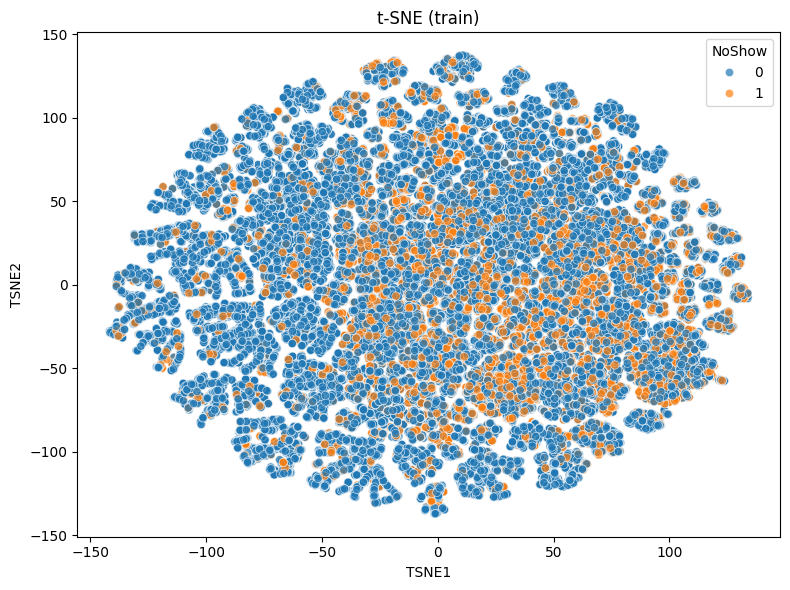

Fitting 5 folds for each of 50 candidates, totalling 250 fits


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:20:14] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Best parameters: {'clf__subsample': 0.7, 'clf__reg_lambda': 1, 'clf__reg_alpha': 0.1, 'clf__n_estimators': 100, 'clf__max_depth': 6, 'clf__learning_rate': 0.02, 'clf__gamma': 0, 'clf__colsample_bytree': 0.9}
Best score (f1): 0.44233383968674256


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:20:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:20:15] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:20:16] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:20:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [02:20:17] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

Results saved in: /content/XG BOOST/outputs/xgboost_cv_results.csv
Summary (median y std) saved in: /content/XG BOOST/outputs/xgboost_cv_summary.csv
\n--- Test metrics ---
Accuracy: 0.5926
Precision: 0.3061
Recall: 0.8033
F1-score: 0.4433
ROC AUC: 0.7294
\nClasification report:\n
              precision    recall  f1-score   support

           0       0.92      0.54      0.68     17642
           1       0.31      0.80      0.44      4464

    accuracy                           0.59     22106
   macro avg       0.61      0.67      0.56     22106
weighted avg       0.79      0.59      0.63     22106



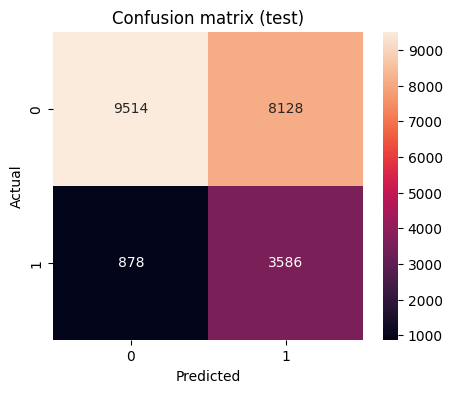

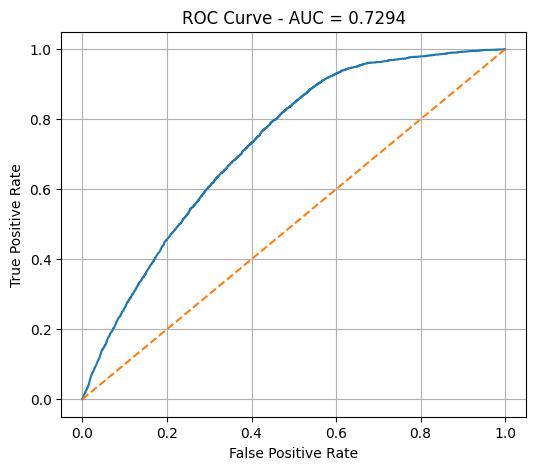

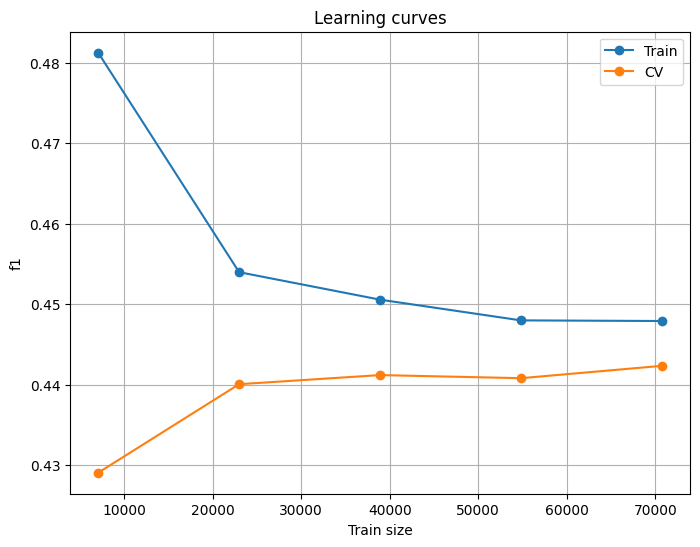

In [ ]:
main(path='data/Cleaned.csv', target_col='NoShow', sampler='ADASYN', random_state=55)